## Mission and Dataset

This notebook trains regression models to predict the Air Quality Index (AQI) using pollutant measurements from multiple Indian cities.

For the full mission description, dataset details, and source, see the project `README.md`. 

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib, os

os.makedirs("outputs", exist_ok=True)
np.random.seed(42)

In [2]:
pip install kagglehub[pandas-datasets]

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Download the dataset locally (cached by kagglehub) and read with pandas
cache_dir = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")
csv_path = os.path.join(cache_dir, "city_day.csv")

df = pd.read_csv(
    csv_path,
    encoding="latin1",
    encoding_errors="ignore",
    sep=",",
    on_bad_lines="skip",
)

df["Year"] = pd.to_datetime(df["Date"], errors="coerce").dt.year
df = df.drop(columns=["Date", "AQI_Bucket"], errors="ignore")

print(f"Shape: {df.shape}\n")
print(df.head())
print("\nMissing values:\n", df.isnull().sum())

Shape: (29531, 15)

        City  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2      O3  \
0  Ahmedabad    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64  133.36   
1  Ahmedabad    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   34.06   
2  Ahmedabad    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   30.70   
3  Ahmedabad    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   36.08   
4  Ahmedabad    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   39.31   

   Benzene  Toluene  Xylene  AQI  Year  
0     0.00     0.02    0.00  NaN  2015  
1     3.68     5.50    3.77  NaN  2015  
2     6.80    16.40    2.25  NaN  2015  
3     4.43    10.14    1.00  NaN  2015  
4     7.01    18.89    2.78  NaN  2015  

Missing values:
 City           0
PM2.5       4598
PM10       11140
NO          3582
NO2         3585
NOx         4185
NH3        10328
CO          2059
SO2         3854
O3          4022
Benzene     5623
Toluene     8041
Xylene     18109
AQI         4681
Year           

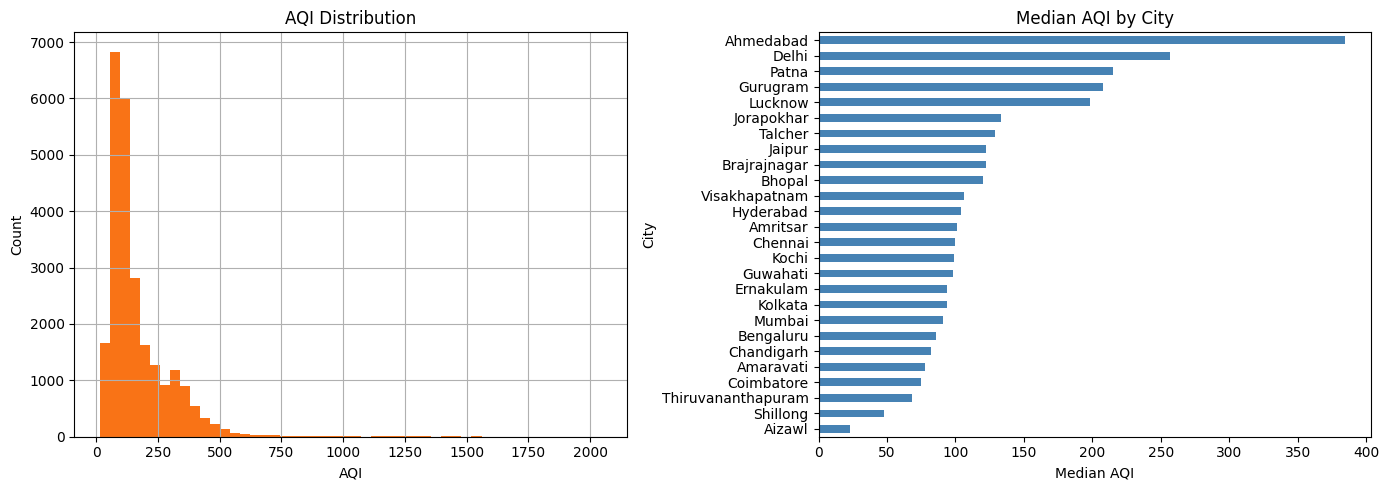

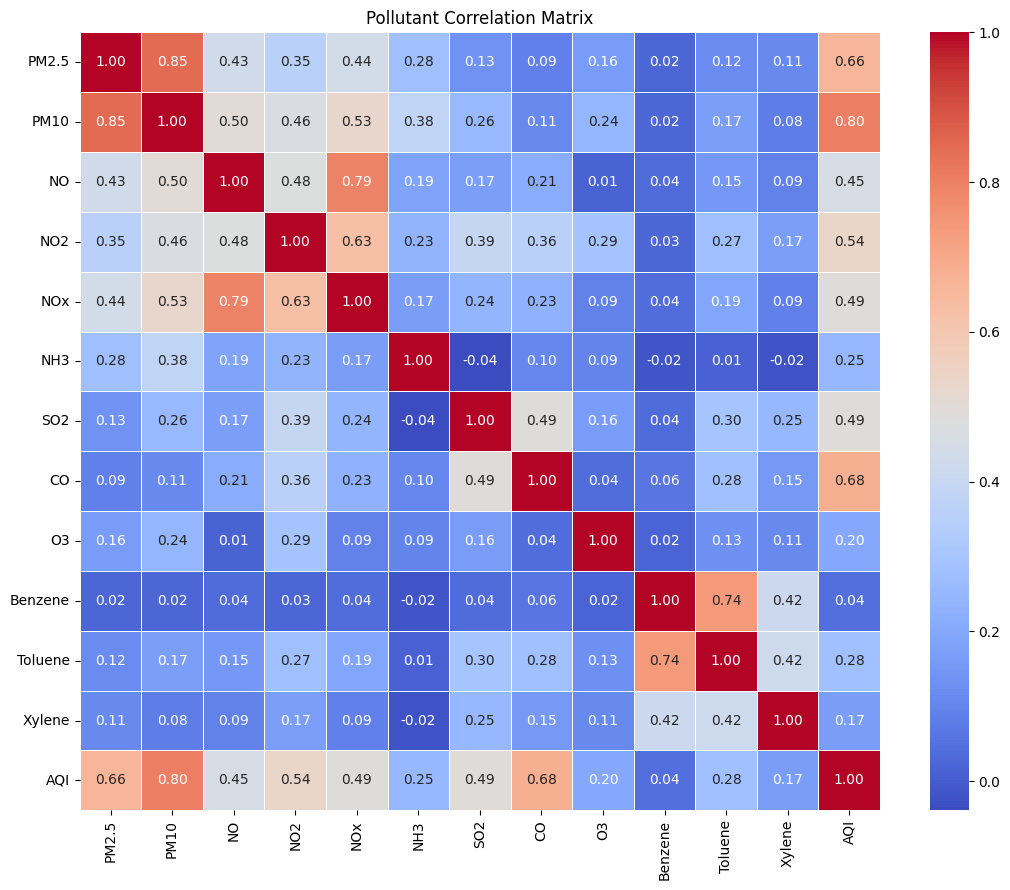

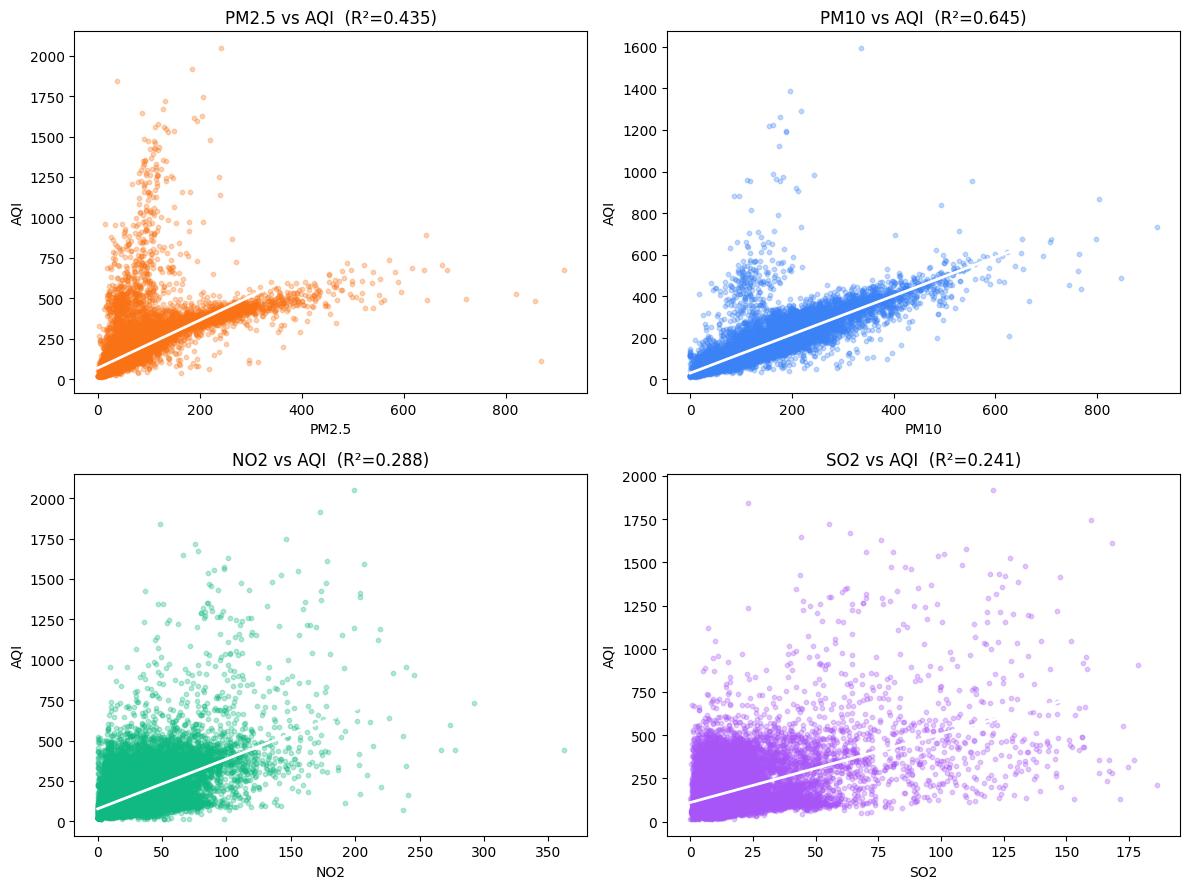


EDA figures saved.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

os.makedirs("outputs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["AQI"].dropna().hist(bins=50, ax=axes[0], color="#f97316")
axes[0].set(title="AQI Distribution", xlabel="AQI", ylabel="Count")

city_aqi = df.groupby("City")["AQI"].median().sort_values()
city_aqi.plot.barh(ax=axes[1], color="steelblue")
axes[1].set(title="Median AQI by City", xlabel="Median AQI")
plt.tight_layout()
plt.show()
plt.savefig("outputs/fig1_distribution.png", dpi=120)
plt.close()

# Fig 2: Correlation heatmap
num_cols = [c for c in ["PM2.5","PM10","NO","NO2","NOx","NH3","SO2","CO","O3","Benzene","Toluene","Xylene","AQI"] if c in df.columns]
plt.figure(figsize=(11, 9))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.4)
plt.title("Pollutant Correlation Matrix")
plt.tight_layout()
plt.show()
plt.savefig("outputs/fig2_correlation.png", dpi=120)
plt.close()

# Fig 3: Top pollutants vs AQI
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat, color in zip(axes.flatten(), ["PM2.5","PM10","NO2","SO2"], ["#f97316","#3b82f6","#10b981","#a855f7"]):
    tmp = df[[feat, "AQI"]].dropna()
    ax.scatter(tmp[feat], tmp["AQI"], alpha=0.3, s=10, color=color)
    m, b = np.polyfit(tmp[feat], tmp["AQI"], 1)
    ax.plot(np.sort(tmp[feat]), m * np.sort(tmp[feat]) + b, "w-", lw=2)
    ax.set(title=f"{feat} vs AQI  (R²={np.corrcoef(tmp[feat], tmp['AQI'])[0,1]**2:.3f})",
           xlabel=feat, ylabel="AQI")
plt.tight_layout()
plt.show()
plt.savefig("outputs/fig3_scatter_pollutants.png", dpi=120)
plt.close()

print("\nEDA figures saved.")

## Exploratory Visualizations (Summary)

- AQI is right‑skewed with some extreme high‑pollution days.
- Cities have different median AQI values, which motivates using a city‑level feature.
- AQI is strongly correlated with PM10, PM2.5 and CO, and moderately with NO2 and SO2.
- Scatter plots confirm that higher pollutant levels generally correspond to higher AQI.

More detailed discussion is in `README.md`. 

In [5]:
print("\nCorrelation with AQI:\n", df[num_cols].corr()["AQI"].sort_values(ascending=False))

# Drop: NOx (multicollinear with NO+NO2), Toluene/Xylene (low correlation), Year (weak predictor)
DROP = [c for c in ["NOx","Toluene","Xylene","Year"] if c in df.columns]
df2 = df.drop(columns=DROP)

# Encode City as ordinal (ranked by city mean AQI)
df2["City_encoded"] = df2["City"].map(df2.groupby("City")["AQI"].mean().rank())
df2 = df2.drop(columns=["City"])

# Impute with median, then drop remaining NaNs
df2 = df2.apply(lambda col: col.fillna(col.median()))
df2 = df2.dropna()

FEATURES = [c for c in df2.columns if c != "AQI"]
print(f"\nFeatures used ({len(FEATURES)}): {FEATURES}")
print(f"Clean dataset: {df2.shape}")


Correlation with AQI:
 AQI        1.000000
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64

Features used (10): ['PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'City_encoded']
Clean dataset: (29531, 11)


## Feature Engineering (Summary)

- Dropped NOx, Toluene, Xylene and Year based on correlation analysis and weak predictive value.
- Encoded City as `City_encoded` (ranked by mean AQI) to capture city‑level pollution differences.
- Imputed missing numeric values with the median and standardized features using `StandardScaler`.

Full reasoning is documented in `README.md`. 

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    df2[FEATURES].values, df2["AQI"].values, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [7]:
# Use the saved best model to predict AQI for one row of the test set
from pathlib import Path

# Make model path robust to where the notebook is launched from.
# Search upward for `summative/linear_regression` and use its `outputs/`.
_base = Path.cwd()
_outputs_dir = None
for _p in [_base, *_base.parents]:
    _candidate = _p / "summative" / "linear_regression"
    if _candidate.exists():
        _outputs_dir = _candidate / "outputs"
        break

if _outputs_dir is None:
    _outputs_dir = _base / "outputs"

_artifact_path = _outputs_dir / "best_aqi_model.pkl"
print(f"Loading model from: {_artifact_path}")

if _artifact_path.exists() and _artifact_path.stat().st_size > 0:
    artifact = joblib.load(str(_artifact_path))
    model = artifact["model"]

    # Take one row from the held‑out test data and predict
    one_row_scaled = X_test_sc[[0]]  # shape (1, n_features)
    predicted_aqi = model.predict(one_row_scaled)[0]
    actual_aqi = y_test[0]

    print(f"Predicted AQI for first test sample: {predicted_aqi:.2f}")
    print(f"Actual AQI for first test sample:    {actual_aqi:.2f}")
else:
    print(
        f"Skipping prediction: model artifact missing/empty at {_artifact_path}. "
        "(Run the 'Save best model' cell first.)"
    )

Loading model from: D:\school\ML\linear_regression_model\summative\linear_regression\outputs\best_aqi_model.pkl
Predicted AQI for first test sample: 116.60
Actual AQI for first test sample:    118.00


In [8]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np



train_loss, test_loss = [], []
sgd = SGDRegressor(loss="squared_error", learning_rate="constant",
                   eta0=0.0001, max_iter=1, warm_start=True, random_state=42, tol=None)

for _ in range(100):
    sgd.fit(X_train_sc, y_train)
    train_loss.append(mean_squared_error(y_train, sgd.predict(X_train_sc)))
    test_loss.append(mean_squared_error(y_test,  sgd.predict(X_test_sc)))

# Loss curve
plt.figure(figsize=(9, 4))
plt.plot(train_loss, label="Train MSE"); plt.plot(test_loss, "--", label="Test MSE")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.title("Gradient Descent — Loss Curve")
plt.legend(); plt.tight_layout(); plt.savefig("outputs/fig4_loss_curve.png", dpi=120); plt.close()

# Before/After scatter
sgd1 = SGDRegressor(loss="squared_error", learning_rate="constant",
                    eta0=0.0001, max_iter=1, random_state=42, tol=None)
sgd1.fit(X_train_sc, y_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title in zip(axes,
    [sgd1.predict(X_test_sc), sgd.predict(X_test_sc)],
    ["BEFORE (Epoch 1)", "AFTER (Epoch 100)"]):
    ax.scatter(y_test, preds, alpha=0.35, s=12)
    lim = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lim, lim, "r--", lw=2, label="Perfect fit")
    ax.set(title=f"{title} — R²={r2_score(y_test, preds):.4f}",
           xlabel="Actual AQI", ylabel="Predicted AQI")
    ax.legend()
plt.tight_layout(); plt.savefig("outputs/fig5_before_after.png", dpi=120); plt.close()

In [9]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)
dt.fit(X_train_sc, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [10]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                            n_jobs=-1, random_state=42)
rf.fit(X_train_sc, y_train)

# Feature importance
pd.Series(rf.feature_importances_, index=FEATURES).sort_values().plot.barh(figsize=(9,5), color="steelblue")
plt.title("Feature Importances — Random Forest")
plt.tight_layout(); plt.savefig("outputs/fig6_feature_importance.png", dpi=120); plt.close()

In [11]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import joblib

def evaluate(model, name):
    p = model.predict(X_test_sc)
    return {"Model": name,
            "Train R²": r2_score(y_train, model.predict(X_train_sc)),
            "Test R²":  r2_score(y_test, p),
            "MAE":      mean_absolute_error(y_test, p),
            "RMSE":     mean_squared_error(y_test, p) ** 0.5}

results = pd.DataFrame([evaluate(sgd, "Linear Regression (GD)"),
                         evaluate(dt,  "Decision Tree"),
                         evaluate(rf,  "Random Forest")])
print("\n", results.to_string(index=False))

# Bar chart comparison
results.set_index("Model")[["Test R²","MAE","RMSE"]].plot.bar(figsize=(10, 5), rot=15)
plt.title("Model Comparison"); plt.tight_layout()
plt.savefig("outputs/fig7_model_comparison.png", dpi=120); plt.close()

# Save best model
best_name = results.loc[results["Test R²"].idxmax(), "Model"]
best_model = {"Linear Regression (GD)": sgd, "Decision Tree": dt, "Random Forest": rf}[best_name]
from pathlib import Path

_base = Path.cwd()
_outputs_dir = None
for _p in [_base, *_base.parents]:
    _candidate = _p / "summative" / "linear_regression"
    if _candidate.exists():
        _outputs_dir = _candidate / "outputs"
        break

if _outputs_dir is None:
    _outputs_dir = _base / "outputs"

_outputs_dir.mkdir(parents=True, exist_ok=True)
_artifact_path = _outputs_dir / "best_aqi_model.pkl"

joblib.dump({"model": best_model, "scaler": scaler, "features": FEATURES}, str(_artifact_path))
print(f"\nBest model: {best_name} → saved to {_artifact_path}")


                  Model  Train R²  Test R²       MAE      RMSE
Linear Regression (GD)  0.794748 0.811964 30.138303 53.802495
         Decision Tree  0.890201 0.866340 23.751168 45.361031
         Random Forest  0.918460 0.887516 20.881572 41.612924

Best model: Random Forest → saved to D:\school\ML\linear_regression_model\summative\linear_regression\outputs\best_aqi_model.pkl
